
<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
            padding: 40px; border-radius: 16px; text-align: center; color: white; margin-bottom: 20px;">
  <h1 style="font-size: 2.2em; margin: 0; letter-spacing: 2px;"> PROJET DE FIN DE MODULE</h1>
  <h2 style="font-size: 1.6em; margin: 10px 0; color: #e94560;">DEEP LEARNING — EMSI</h2>
  <h2 style="font-size: 1.6em; margin: 10px 0; color: #e94560;">Hajar Belhachmi</h2>
  <h3 style="font-size: 1.3em; margin: 10px 0; color: #a8dadc;">Année universitaire 2025–2026</h3>
  <hr style="border: 1px solid #e94560; margin: 20px 0;">
  <h2 style="font-size: 1.5em; color: #f1f1f1;">PARTIE I — MLP</h2>
  <p style="font-size: 1.1em; color: #c0c0c0;">Classification supervisée sur données tabulaires réelles</p>
  <p style="font-size: 1em; color: #a8dadc;">Dataset : <strong>Breast Cancer Wisconsin</strong></p>
</div>

---

##  Table des Matières

| # | Section | Description |
|---|---------|-------------|
| 0 | [Installations & Imports](#0) | Environnement et bibliothèques |
| 1 | [Concepts Fondamentaux](#1) | nn.Module, gradient, state_dict, device |
| 2 | [Préparation des Données](#2) | Nettoyage, normalisation, split |
| 3 | [Device CPU/GPU](#3) | Gestion du device PyTorch |
| 4 | [MLP — nn.Sequential](#4) | Première implémentation |
| 5 | [MLP — Classe Personnalisée](#5) | Deuxième implémentation |
| 6 | [Inspection des Paramètres](#6) | named_parameters() et state_dict() |
| 7 | [Stratégies d'Initialisation](#7) | Gaussienne, Constante, Xavier |
| 8 | [Entraînement](#8) | Boucle d'entraînement complète |
| 9 | [Sauvegarde / Rechargement](#9) | Persistance du meilleur modèle |
| 10 | [Évaluation des Performances](#10) | Accuracy, F1, Matrice de confusion |
| 11 | [Visualisations](#11) | Courbes et graphiques |
| 12 | [Question de Synthèse](#12) | Analyse critique et conclusions |

---
>  &nbsp;|&nbsp; Filière : Intelligence Artificielle et Science des Données   &nbsp;|&nbsp; **Groupe :** Groupe 2



---
<a id="0"></a>
##  Section 0 — Installations & Imports

###  Objectif
Mettre en place l'environnement de travail complet. Toutes les bibliothèques nécessaires sont listées avec leur rôle spécifique dans ce projet.

###  Bibliothèques utilisées

| Bibliothèque | Version minimale | Rôle dans ce projet |
|---|---|---|
| `torch` | 2.0+ | Framework deep learning — construction et entraînement du MLP |
| `torch.nn` | — | Couches de réseau (Linear, BatchNorm, Dropout, ReLU) |
| `torch.optim` | — | Optimiseurs (Adam) et schedulers |
| `numpy` | 1.23+ | Calculs numériques, manipulation des arrays |
| `pandas` | 1.5+ | Chargement et exploration du dataset tabulaire |
| `matplotlib` | 3.6+ | Visualisation des courbes d'apprentissage |
| `seaborn` | 0.12+ | Heatmap de la matrice de confusion |
| `sklearn` | 1.2+ | Dataset, préprocessing, métriques d'évaluation |

###  Reproductibilité
La graine aléatoire (`SEED = 42`) est fixée dans NumPy et PyTorch pour garantir des résultats reproductibles d'une exécution à l'autre.


In [2]:
# ─── Installer si nécessaire ───
# !pip install torch scikit-learn pandas numpy matplotlib seaborn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import os, warnings
warnings.filterwarnings("ignore")

# ─── Reproductibilité ───────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ─── Style des graphiques ───────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

print(" Environnement initialisé")
print(f"   PyTorch version  : {torch.__version__}")
print(f"   NumPy version    : {np.__version__}")
print(f"   Pandas version   : {pd.__version__}")


 Environnement initialisé
   PyTorch version  : 2.11.0+cpu
   NumPy version    : 2.4.4
   Pandas version   : 3.0.2



---
<a id="1"></a>
##  Section 1 — Concepts Fondamentaux PyTorch

###  Objectif
Présenter et démontrer par l'exemple les briques de base de PyTorch que nous utiliserons tout au long de ce projet. La maîtrise de ces concepts est indispensable pour comprendre le fonctionnement interne du MLP.

---

### 1.1 `nn.Module` — La classe de base de tout modèle PyTorch

`nn.Module` est la classe parent de tous les modèles PyTorch. Elle fournit :
- **Enregistrement automatique** des paramètres (poids, biais) via `__init__`
- **Méthode `forward()`** à surcharger pour définir le calcul
- **Outils de gestion** : sauvegarde, chargement, déplacement sur device, mode train/eval

```
Modèle PyTorch = nn.Module
    ├── Paramètres (nn.Parameter, tenseurs avec requires_grad=True)
    ├── Sous-modules (autres nn.Module)
    ├── forward() → calcul de la prédiction
    └── backward() → calcul automatique des gradients (via autograd)
```

---

### 1.2 Paramètre (`nn.Parameter`)
Un `nn.Parameter` est un **tenseur apprenable** : `requires_grad=True` indique à PyTorch de calculer le gradient de la loss par rapport à ce tenseur lors de la rétropropagation.

---

### 1.3 Gradient & Autograd
Le gradient $\frac{\partial \mathcal{L}}{\partial \theta}$ mesure l'impact d'un paramètre $\theta$ sur la loss $\mathcal{L}$. PyTorch construit un **graphe de calcul dynamique** (define-by-run) et calcule les gradients via la règle de chaîne :

$$\frac{\partial \mathcal{L}}{\partial \theta_1} = \frac{\partial \mathcal{L}}{\partial z_n} \cdot \frac{\partial z_n}{\partial z_{n-1}} \cdots \frac{\partial z_2}{\partial \theta_1}$$

---

### 1.4 `state_dict()`
Dictionnaire `{nom_couche → tensor_poids}` représentant l'état complet du modèle. Utilisé pour la **sauvegarde** et le **rechargement** des poids.

---

### 1.5 Device (CPU / GPU)
PyTorch permet de déplacer modèles et tenseurs sur **CPU** ou **GPU (CUDA)**. La règle absolue est : **données et modèle doivent être sur le même device**.

---

### 1.6 Propagation avant → Rétropropagation

```
Entrée X ──→ [Couche 1] ──→ [Activation] ──→ ... ──→ Sortie ŷ   (FORWARD)
                                                              ↓
                                                         Loss L(ŷ, y)
                                                              ↓
Mise à jour θ ←── [optimizer.step()] ←── [backward()]          (BACKWARD)
```


In [3]:
import torch
import torch.nn as nn

# ─── DÉMONSTRATION 1 : nn.Module simple ──────────────────────────
print("=" * 60)
print("DÉMONSTRATION — Concepts Fondamentaux PyTorch")
print("=" * 60)

# Création d'un module minimal
class DemoModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(3, 1)   # paramètres : weight(1x3) + bias(1)

    def forward(self, x):
        return self.fc(x)

demo = DemoModule()

# ─── DÉMONSTRATION 2 : Paramètres et gradients ───────────────────
x = torch.randn(2, 3, requires_grad=False)  # 2 exemples, 3 features
y = torch.tensor([[1.0], [0.0]])

print("\n 1. Paramètres du module :")
for name, param in demo.named_parameters():
    print(f"   {name:15s} | shape={param.shape} | requires_grad={param.requires_grad}")

# Propagation avant
y_hat = demo(x)
print(f"\n 2. Propagation avant :")
print(f"   Entrée X : shape={x.shape}")
print(f"   Sortie ŷ : shape={y_hat.shape}  valeurs={y_hat.detach().numpy().flatten()}")

# Calcul de la loss
loss = nn.MSELoss()(y_hat, y)
print(f"\n 3. Loss (MSE) = {loss.item():.6f}")

# Rétropropagation
loss.backward()
print(f"\n 4. Gradients après backward() :")
for name, param in demo.named_parameters():
    print(f"   ∂L/∂{name:10s} = {param.grad.numpy().flatten()}")

# ─── DÉMONSTRATION 3 : state_dict ────────────────────────────────
print(f"\n 5. state_dict() :")
for k, v in demo.state_dict().items():
    print(f"   '{k}' → shape={v.shape}")

# ─── DÉMONSTRATION 4 : Mode train vs eval ────────────────────────
demo.train()
print(f"\n 6. Mode training  : demo.training = {demo.training}")

demo.eval()
print(f"   Mode evaluation  : demo.training = {demo.training}")

DÉMONSTRATION — Concepts Fondamentaux PyTorch

 1. Paramètres du module :
   fc.weight       | shape=torch.Size([1, 3]) | requires_grad=True
   fc.bias         | shape=torch.Size([1]) | requires_grad=True

 2. Propagation avant :
   Entrée X : shape=torch.Size([2, 3])
   Sortie ŷ : shape=torch.Size([2, 1])  valeurs=[0.89610493 1.5925894 ]

 3. Loss (MSE) = 1.273568

 4. Gradients après backward() :
   ∂L/∂fc.weight  = [-0.32110393  3.4928277  -0.89940804]
   ∂L/∂fc.bias    = [1.4886943]

 5. state_dict() :
   'fc.weight' → shape=torch.Size([1, 3])
   'fc.bias' → shape=torch.Size([1])

 6. Mode training  : demo.training = True
   Mode evaluation  : demo.training = False



---
<a id="2"></a>
##  Section 2 — Préparation des Données

###  Objectif
Appliquer un pipeline complet de préparation des données, indispensable avant tout entraînement d'un réseau de neurones. Un MLP est sensible à l'échelle des features et à la qualité des données.

---

### 2.1 Choix du Dataset : Breast Cancer Wisconsin

**Pourquoi ce dataset ?**
-  Dataset tabulaire réel, bien documenté (UCI Machine Learning Repository)
-  Disponible nativement dans scikit-learn (pas de téléchargement)
-  Classification binaire (malin / bénin) — problème médical concret
-  30 features numériques continues → parfait pour un MLP
-  Taille raisonnable (569 exemples) → entraînement rapide sans GPU

**Description des features :**
10 caractéristiques cellulaires sont mesurées (rayon, texture, périmètre, aire, lissé, compacité, concavité, points concaves, symétrie, dimension fractale), chacune déclinée en 3 statistiques (mean, error, worst) → **30 features au total**.

---

### 2.2 Pipeline de préparation

```
Dataset brut
    │
    ├─ [Exploration] → distribution, valeurs manquantes, classes
    │
    ├─ [Nettoyage] → valeurs manquantes, outliers
    │
    ├─ [Normalisation] → StandardScaler : µ=0, σ=1 par feature
    │       Pourquoi ? Un MLP avec ReLU est très sensible à l'échelle.
    │       Sans normalisation, les features avec grandes valeurs dominent.
    │
    └─ [Split] → Train 70% / Validation 15% / Test 15%
            Pourquoi 3 splits ?
            - Train    : apprentissage des poids
            - Val      : tuning hyperparamètres + early stopping
            - Test     : évaluation finale non biaisée
```

---

### 2.3 Justification de la normalisation StandardScaler

Le `StandardScaler` centre et réduit chaque feature $j$ :
$$x_j' = \frac{x_j - \mu_j}{\sigma_j}$$

Cette transformation garantit que toutes les features ont la même plage de variation, ce qui :
1. **Stabilise les gradients** (pas d'explosion/vanishing due aux échelles différentes)
2. **Accélère la convergence** (condition de Hessien mieux conditionnée)
3. **Améliore les performances** des régularisations (dropout, weight decay)

>  **Important** : le scaler est ajusté (`fit`) **uniquement sur le train**, puis appliqué (`transform`) sur val et test pour éviter la **data leakage**.


In [4]:
# ─── 2.1 Chargement du dataset ───────────────────────────────────
data = load_breast_cancer()
X_raw = pd.DataFrame(data.data, columns=data.feature_names)
y_raw = pd.Series(data.target, name="target")

print("=" * 60)
print("DATASET : Breast Cancer Wisconsin")
print("=" * 60)
print(f"\n Dimensions       : {X_raw.shape[0]} exemples × {X_raw.shape[1]} features")
print(f"  Classes           : {list(data.target_names)}")
print(f"                       0 = Malin (cancéreux), 1 = Bénin")

# Distribution des classes
vc = y_raw.value_counts()
print(f"\n Distribution des classes :")
print(f"   Bénin  (1) : {vc[1]} exemples ({100*vc[1]/len(y_raw):.1f}%)")
print(f"   Malin  (0) : {vc[0]} exemples ({100*vc[0]/len(y_raw):.1f}%)")
print(f"   → Léger déséquilibre à considérer dans l'évaluation")


DATASET : Breast Cancer Wisconsin

 Dimensions       : 569 exemples × 30 features
  Classes           : [np.str_('malignant'), np.str_('benign')]
                       0 = Malin (cancéreux), 1 = Bénin

 Distribution des classes :
   Bénin  (1) : 357 exemples (62.7%)
   Malin  (0) : 212 exemples (37.3%)
   → Léger déséquilibre à considérer dans l'évaluation


In [5]:
# ─── 2.2 Exploration statistique ─────────────────────────────────
print("\n Statistiques descriptives (5 premières features) :")
print(X_raw.iloc[:, :5].describe().round(3).to_string())



 Statistiques descriptives (5 premières features) :
       mean radius  mean texture  mean perimeter  mean area  mean smoothness
count      569.000       569.000         569.000    569.000          569.000
mean        14.127        19.290          91.969    654.889            0.096
std          3.524         4.301          24.299    351.914            0.014
min          6.981         9.710          43.790    143.500            0.053
25%         11.700        16.170          75.170    420.300            0.086
50%         13.370        18.840          86.240    551.100            0.096
75%         15.780        21.800         104.100    782.700            0.105
max         28.110        39.280         188.500   2501.000            0.163


In [6]:
# ─── 2.3 Vérification de la qualité des données ──────────────────
print("\n Contrôle qualité :")
missing = X_raw.isnull().sum().sum()
duplicates = X_raw.duplicated().sum()
print(f"   Valeurs manquantes : {missing}  {' Aucune' if missing == 0 else ' À traiter'}")
print(f"   Doublons           : {duplicates}  {' Aucun' if duplicates == 0 else ' À traiter'}")
print(f"   Types de données   : {X_raw.dtypes.unique()}  (tous numériques )")
print("   → Aucun prétraitement de nettoyage nécessaire pour ce dataset")



 Contrôle qualité :
   Valeurs manquantes : 0   Aucune
   Doublons           : 0   Aucun
   Types de données   : [dtype('float64')]  (tous numériques )
   → Aucun prétraitement de nettoyage nécessaire pour ce dataset


In [7]:
# ─── 2.4 Normalisation ───────────────────────────────────────────
# D'abord : split train/temp (puis temp → val + test)
# La normalisation est FIT uniquement sur train → évite data leakage

X_train_raw, X_temp, y_train, y_temp = train_test_split(
    X_raw.values, y_raw.values,
    test_size=0.30, random_state=SEED, stratify=y_raw
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50, random_state=SEED, stratify=y_temp
)

# Ajustement du scaler UNIQUEMENT sur train
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)   # fit + transform sur train
X_val   = scaler.transform(X_val_raw)          # transform seul sur val
X_test  = scaler.transform(X_test_raw)         # transform seul sur test

print(" Normalisation StandardScaler appliquée")
print(f"   Avant : X_train mean={X_train_raw.mean():.2f}, std={X_train_raw.std():.2f}")
print(f"   Après : X_train mean={X_train.mean():.4f},  std={X_train.std():.4f}  (µ≈0, σ≈1)")

print(f"\n Répartition finale :")
print(f"   Train      : {len(X_train):4d} exemples  ({100*len(X_train)/len(y_raw):.0f}%)")
print(f"   Validation : {len(X_val):4d} exemples  ({100*len(X_val)/len(y_raw):.0f}%)")
print(f"   Test       : {len(X_test):4d} exemples  ({100*len(X_test)/len(y_raw):.0f}%)")


 Normalisation StandardScaler appliquée
   Avant : X_train mean=61.64, std=226.84
   Après : X_train mean=-0.0000,  std=1.0000  (µ≈0, σ≈1)

 Répartition finale :
   Train      :  398 exemples  (70%)
   Validation :   85 exemples  (15%)
   Test       :   86 exemples  (15%)


In [8]:
# ─── 2.5 Conversion en Tenseurs PyTorch et DataLoaders ───────────
def arrays_to_tensors(X, y):
    """Convertit des arrays numpy en tenseurs PyTorch."""
    return (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)   # long requis par CrossEntropyLoss
    )

X_tr, y_tr = arrays_to_tensors(X_train, y_train)
X_va, y_va = arrays_to_tensors(X_val,   y_val)
X_te, y_te = arrays_to_tensors(X_test,  y_test)

BATCH_SIZE = 32  # Mini-batch SGD : compromis vitesse / stabilité gradient

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_va, y_va), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_te, y_te), batch_size=BATCH_SIZE, shuffle=False)

print(" Tenseurs PyTorch créés :")
print(f"   X_train : {X_tr.shape}  dtype={X_tr.dtype}")
print(f"   y_train : {y_tr.shape}  dtype={y_tr.dtype}")
print(f"\n DataLoaders créés (batch_size={BATCH_SIZE}) :")
print(f"   Train   : {len(train_loader)} batches")
print(f"   Val     : {len(val_loader)} batches")
print(f"   Test    : {len(test_loader)} batches")

# Constantes globales
INPUT_DIM  = X_train.shape[1]   # 30 features
OUTPUT_DIM = 2                   # 2 classes : malin / bénin
HIDDEN1    = 64
HIDDEN2    = 32


 Tenseurs PyTorch créés :
   X_train : torch.Size([398, 30])  dtype=torch.float32
   y_train : torch.Size([398])  dtype=torch.int64

 DataLoaders créés (batch_size=32) :
   Train   : 13 batches
   Val     : 3 batches
   Test    : 3 batches



---
<a id="3"></a>
##  Section 3 — Gestion du Device (CPU / GPU)

###  Objectif
Détecter automatiquement le hardware disponible et s'assurer que modèle et données sont toujours sur le même device. C'est une bonne pratique essentielle pour écrire du code PyTorch portable.

---

### Pourquoi la gestion du device est-elle critique ?

PyTorch impose une règle stricte : **toute opération entre tenseurs doit impliquer des tenseurs sur le même device**. Mélanger CPU et GPU provoque une `RuntimeError` immédiate.

**Bonne pratique :** définir `device` en une ligne et l'utiliser systématiquement :
```python
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
X_batch = X_batch.to(device)
```

### CPU vs GPU pour notre projet

| Critère | CPU | GPU (CUDA) |
|---|---|---|
| Dataset Breast Cancer (569 ex.) |  Suffisant | Overhead inutile |
| Entraînement ~80 époques |  < 30 sec | Plus rapide, mais inutile |
| Code portable |  Toujours dispo | Nécessite NVIDIA |

> Pour ce dataset de taille modeste, le CPU est parfaitement adapté. Le code détecte et utilise automatiquement le GPU si disponible.


In [9]:
# ─── Détection automatique du device ─────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("GESTION DU DEVICE")
print("=" * 60)
print(f"\n  Device sélectionné : {device}")

if device.type == "cuda":
    print(f"   GPU : {torch.cuda.get_device_name(0)}")
    total_mem = torch.cuda.get_device_properties(0).total_memory
    print(f"   Mémoire totale : {total_mem / 1e9:.2f} Go")
    print(f"   CUDA version   : {torch.version.cuda}")
else:
    print("   ℹ  Aucun GPU NVIDIA détecté → exécution sur CPU")
    print("    Parfaitement adapté pour Breast Cancer Wisconsin")

print(f"\n Convention utilisée dans tout le notebook :")
print(f"   model = model.to(device)   # déplace le modèle")
print(f"   X, y  = X.to(device), y.to(device)  # dans la boucle d'entraînement")


GESTION DU DEVICE

  Device sélectionné : cpu
   ℹ  Aucun GPU NVIDIA détecté → exécution sur CPU
    Parfaitement adapté pour Breast Cancer Wisconsin

 Convention utilisée dans tout le notebook :
   model = model.to(device)   # déplace le modèle
   X, y  = X.to(device), y.to(device)  # dans la boucle d'entraînement



---
<a id="4"></a>
##  Section 4 — MLP Version A : `nn.Sequential`

###  Objectif
Implémenter un MLP en utilisant `nn.Sequential`, l'approche la plus concise de PyTorch pour des architectures linéaires (couche après couche sans branchements).

---

### Qu'est-ce que `nn.Sequential` ?

`nn.Sequential` est un conteneur qui enchaîne des modules PyTorch dans l'ordre de leur déclaration. La méthode `forward()` est générée automatiquement : la sortie de chaque couche devient l'entrée de la suivante.

**Avantages :**
-  Code très concis et lisible pour des architectures simples
-  Pas besoin de définir `forward()` manuellement
-  Idéal pour le prototypage rapide

**Limitations :**
-  Impossible d'avoir des connexions résiduelles, des branches parallèles
-  Pas d'accès direct aux représentations intermédiaires
-  Moins flexible pour des architectures complexes (ResNet, U-Net, etc.)

---

### Architecture choisie

```
Entrée (30)
    │
    ▼
[Linear 30→64] → [ReLU] → [Dropout 30%]
    │
    ▼
[Linear 64→32] → [ReLU] → [Dropout 20%]
    │
    ▼
[Linear 32→2]   ← logits (pas de Softmax ici : intégré dans CrossEntropyLoss)
    │
    ▼
Sortie : 2 logits (malin, bénin)
```

### Justification des choix architecturaux

| Composant | Valeur choisie | Justification |
|---|---|---|
| Couches cachées | 2 | Suffisant pour données tabulaires simples |
| Neurones H1 | 64 | ≈ 2× le nb de features (heuristique courante) |
| Neurones H2 | 32 | Réduction progressive → compression de représentation |
| Activation | ReLU | Standard, évite le vanishing gradient vs sigmoid/tanh |
| Dropout H1 | 30% | Régularisation forte (petite taille dataset) |
| Dropout H2 | 20% | Régularisation plus légère vers la sortie |
| Sortie | Linear(32,2) | Logits bruts → CrossEntropyLoss gère le softmax |


In [10]:
# ─── Architecture MLP avec nn.Sequential ────────────────────────
mlp_sequential = nn.Sequential(
    # ── Couche 1 ──────────────────────────────────
    nn.Linear(INPUT_DIM, HIDDEN1),   # 30 → 64 : expansion de représentation
    nn.ReLU(),                        # Activation non-linéaire : max(0, x)
    nn.Dropout(p=0.30),              # Désactivation aléatoire 30% des neurones

    # ── Couche 2 ──────────────────────────────────
    nn.Linear(HIDDEN1, HIDDEN2),     # 64 → 32 : compression
    nn.ReLU(),
    nn.Dropout(p=0.20),              # Régularisation moins agressive

    # ── Couche de sortie ──────────────────────────
    nn.Linear(HIDDEN2, OUTPUT_DIM)   # 32 → 2 logits (malin, bénin)
).to(device)

print("=" * 60)
print("MLP VERSION A — nn.Sequential")
print("=" * 60)
print(mlp_sequential)

# ─── Comptage des paramètres ─────────────────────────────────────
total = sum(p.numel() for p in mlp_sequential.parameters() if p.requires_grad)
print(f"\n Paramètres entraînables : {total:,}")

# ─── Test de la propagation avant ────────────────────────────────
x_test = torch.randn(4, INPUT_DIM).to(device)   # 4 exemples factices
with torch.no_grad():
    out = mlp_sequential(x_test)
print(f"\n Test propagation avant : entrée {x_test.shape} → sortie {out.shape}")
print(f"   Logits (4 premiers ex.) :\n{out.numpy()}")


MLP VERSION A — nn.Sequential
Sequential(
  (0): Linear(in_features=30, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=32, out_features=2, bias=True)
)

 Paramètres entraînables : 4,130

 Test propagation avant : entrée torch.Size([4, 30]) → sortie torch.Size([4, 2])
   Logits (4 premiers ex.) :
[[ 0.22259033  0.02448349]
 [-0.17154415 -0.03330248]
 [ 0.10159802 -0.07456088]
 [ 0.04943322  0.00079252]]



---
<a id="5"></a>
##  Section 5 — MLP Version B : Classe Personnalisée (`nn.Module`)

###  Objectif
Implémenter le même MLP via une classe qui hérite de `nn.Module`. Cette approche offre un contrôle total sur l'architecture et est indispensable pour des modèles complexes.

---

### Différences clés vs `nn.Sequential`

| Aspect | `nn.Sequential` | Classe personnalisée |
|---|---|---|
| `forward()` | Automatique | Défini manuellement → contrôle total |
| Connexions résiduelles | non | oui |
| Branches multiples | non | oui|
| Accès aux activations intermédiaires | non | oui |
| Lisibilité de l'architecture | Bonne | Excellente |
| Recommandée pour | Prototypage | Production, recherche |

---

### Améliorations apportées vs Version A

Cette version personnalisée ajoute le **BatchNormalization** après chaque couche linéaire, avant l'activation.

**Pourquoi BatchNorm ?**

Le `BatchNorm1d` normalise les activations d'une couche au sein d'un mini-batch :
$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}} \cdot \gamma + \beta$$

Effets bénéfiques :
1. **Réduit le covariate shift interne** → chaque couche reçoit des entrées mieux distribuées
2. **Permet un learning rate plus élevé** → convergence plus rapide
3. **Agit comme régularisateur** → réduit parfois le besoin de Dropout

---

### Architecture complète

```
Entrée (30)
    │
    ▼
[Linear 30→64] → [BatchNorm1d(64)] → [ReLU] → [Dropout 30%]
    │
    ▼
[Linear 64→32] → [BatchNorm1d(32)] → [ReLU] → [Dropout 15%]
    │
    ▼
[Linear 32→2]  → logits
```


In [11]:
# ─── Définition de la classe MLPClassifier ───────────────────────
class MLPClassifier(nn.Module):
    """
    Perceptron Multicouche personnalisé pour classification binaire.

    Architecture :
        Linear → BatchNorm1d → ReLU → Dropout  (x2 couches cachées)
        Linear → logits (sortie)

    Args:
        input_dim  : Nombre de features d'entrée
        hidden1    : Neurones dans la 1ère couche cachée
        hidden2    : Neurones dans la 2ème couche cachée
        output_dim : Nombre de classes (2 pour binaire)
        dropout    : Taux de Dropout pour la 1ère couche cachée
    """
    def __init__(self, input_dim, hidden1, hidden2, output_dim, dropout=0.30):
        super(MLPClassifier, self).__init__()

        # ── Couche cachée 1 ───────────────────────────────────────
        self.fc1   = nn.Linear(input_dim, hidden1)    # Transformation affine
        self.bn1   = nn.BatchNorm1d(hidden1)           # Normalisation du batch
        self.act1  = nn.ReLU()                         # Activation non-linéaire
        self.drop1 = nn.Dropout(p=dropout)             # Régularisation

        # ── Couche cachée 2 ───────────────────────────────────────
        self.fc2   = nn.Linear(hidden1, hidden2)
        self.bn2   = nn.BatchNorm1d(hidden2)
        self.act2  = nn.ReLU()
        self.drop2 = nn.Dropout(p=dropout / 2)        # Régularisation plus légère

        # ── Couche de sortie ──────────────────────────────────────
        self.fc3   = nn.Linear(hidden2, output_dim)    # Logits bruts

    def forward(self, x):
        """
        Propagation avant explicite.
        Lecture directe du flux d'information à travers le réseau.
        """
        # Couche 1 : Linear → BatchNorm → ReLU → Dropout
        x = self.fc1(x)    # Transformation linéaire : W1·x + b1
        x = self.bn1(x)    # Normalisation intra-batch
        x = self.act1(x)   # Non-linéarité : max(0, x)
        x = self.drop1(x)  # Masquage aléatoire 30% des neurones (mode train)

        # Couche 2 : Linear → BatchNorm → ReLU → Dropout
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.drop2(x)

        # Sortie : logits bruts (CrossEntropyLoss intègre le softmax)
        x = self.fc3(x)
        return x

# ─── Instanciation ───────────────────────────────────────────────
mlp_custom = MLPClassifier(
    input_dim  = INPUT_DIM,
    hidden1    = HIDDEN1,
    hidden2    = HIDDEN2,
    output_dim = OUTPUT_DIM,
    dropout    = 0.30
).to(device)

print("=" * 60)
print("MLP VERSION B — Classe Personnalisée MLPClassifier")
print("=" * 60)
print(mlp_custom)

total_custom = sum(p.numel() for p in mlp_custom.parameters() if p.requires_grad)
print(f"\n Paramètres entraînables : {total_custom:,}")
print(f"   (dont BatchNorm : 2 × (64+32) × 2 = {2*(64+32)*2} params γ et β)")

# ─── Test propagation avant ──────────────────────────────────────
mlp_custom.eval()
with torch.no_grad():
    out = mlp_custom(x_test)
print(f"\n Test propagation avant : entrée {x_test.shape} → sortie {out.shape}")
mlp_custom.train()


MLP VERSION B — Classe Personnalisée MLPClassifier
MLPClassifier(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU()
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act2): ReLU()
  (drop2): Dropout(p=0.15, inplace=False)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
)

 Paramètres entraînables : 4,322
   (dont BatchNorm : 2 × (64+32) × 2 = 384 params γ et β)

 Test propagation avant : entrée torch.Size([4, 30]) → sortie torch.Size([4, 2])


MLPClassifier(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU()
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act2): ReLU()
  (drop2): Dropout(p=0.15, inplace=False)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
)


---
<a id="6"></a>
##  Section 6 — Inspection des Paramètres du Modèle

###  Objectif
Utiliser `named_parameters()` et `state_dict()` pour inspecter, analyser et comprendre la structure interne des paramètres du modèle.

---

### `named_parameters()` vs `state_dict()` — Différences

| Méthode | Contenu | Usage principal |
|---|---|---|
| `named_parameters()` | Itérable de `(nom, Parameter)` — **uniquement les params apprenables** | Debug, inspection des gradients, initialisation |
| `state_dict()` | Dict `{nom: Tensor}` — **tous les buffers** (incl. running_mean de BatchNorm) | Sauvegarde, rechargement, transfert |

> **Pourquoi state_dict() contient plus de clés que named_parameters() ?**
> `BatchNorm1d` maintient des buffers non-apprenables (`running_mean`, `running_var`, `num_batches_tracked`) qui doivent être sauvegardés mais ne reçoivent pas de gradient.


In [12]:
# ─── 6.1 Inspection avec named_parameters() ──────────────────────
print("=" * 60)
print("INSPECTION DES PARAMÈTRES — Classe Personnalisée")
print("=" * 60)

print("\n named_parameters() — Paramètres apprenables :")
print(f"{'Nom':<28} {'Shape':<22} {'#Params':>8} {'requires_grad'}")
print("─" * 70)
total = 0
for name, param in mlp_custom.named_parameters():
    n = param.numel()
    total += n
    print(f"{name:<28} {str(param.shape):<22} {n:>8,}  {param.requires_grad}")
print("─" * 70)
print(f"{'TOTAL':>52} {total:>8,}")

# ─── 6.2 Inspection avec state_dict() ────────────────────────────
print("\n\n state_dict() — Tous les buffers (dont BatchNorm) :")
print(f"{'Clé':<33} {'Shape':<22} {'Apprenable ?'}")
print("─" * 65)
param_names = {n for n, _ in mlp_custom.named_parameters()}
for k, v in mlp_custom.state_dict().items():
    learnable = "Oui" if k in param_names else "🔵 Buffer"
    print(f"{k:<33} {str(v.shape):<22} {learnable}")

# ─── 6.3 Statistiques des poids initiaux ─────────────────────────
print("\n\n Statistiques des poids avant initialisation explicite :")
print(f"{'Couche':<10} {'Mean':>12} {'Std':>12} {'Min':>12} {'Max':>12}")
print("─" * 55)
for name, module in mlp_custom.named_modules():
    if isinstance(module, nn.Linear):
        w = module.weight.data
        print(f"{name:<10} {w.mean().item():>12.6f} {w.std().item():>12.6f} {w.min().item():>12.6f} {w.max().item():>12.6f}")


INSPECTION DES PARAMÈTRES — Classe Personnalisée

 named_parameters() — Paramètres apprenables :
Nom                          Shape                   #Params requires_grad
──────────────────────────────────────────────────────────────────────
fc1.weight                   torch.Size([64, 30])      1,920  True
fc1.bias                     torch.Size([64])             64  True
bn1.weight                   torch.Size([64])             64  True
bn1.bias                     torch.Size([64])             64  True
fc2.weight                   torch.Size([32, 64])      2,048  True
fc2.bias                     torch.Size([32])             32  True
bn2.weight                   torch.Size([32])             32  True
bn2.bias                     torch.Size([32])             32  True
fc3.weight                   torch.Size([2, 32])          64  True
fc3.bias                     torch.Size([2])               2  True
──────────────────────────────────────────────────────────────────────
                


---
<a id="7"></a>
##  Section 7 — Stratégies d'Initialisation des Poids

###  Objectif
Comparer expérimentalement trois stratégies d'initialisation et justifier le choix de Xavier Uniform pour notre modèle final.

---

### Pourquoi l'initialisation des poids est-elle cruciale ?

Une mauvaise initialisation peut causer :
- **Vanishing gradient** (poids trop petits) : les gradients des couches profondes deviennent $\approx 0$, l'apprentissage stagne
- **Exploding gradient** (poids trop grands) : les gradients divergent, l'entraînement explose
- **Symétrie des neurones** (poids identiques) : tous les neurones apprennent la même chose → réseau équivalent à 1 neurone

---

### Les trois stratégies comparées

#### 1. Initialisation Gaussienne
$$W \sim \mathcal{N}(0, \sigma^2)  \quad \text{avec } \sigma = 0.01$$
- Simple et intuitive
- Problème : `σ=0.01` peut être trop petit → vanishing gradient pour des réseaux profonds

#### 2. Initialisation Constante
$$W_{ij} = c  \quad \forall i, j \quad (c = 0.01)$$
-  **Mauvaise pratique** : brise la symétrie entre neurones mais tous les neurones d'une couche reçoivent les mêmes gradients → équivalent à 1 neurone par couche
- Utilisée ici uniquement pour illustration

#### 3. Initialisation Xavier (Glorot) Uniform 
$$W \sim \mathcal{U}\left(-\sqrt{\frac{6}{n_{in} + n_{out}}}, +\sqrt{\frac{6}{n_{in} + n_{out}}}\right)$$
- Conçue pour maintenir la **variance des activations et des gradients** constante à travers les couches
- **Hypothèse** : activations linéaires ou tangente hyperbolique (marche aussi bien avec ReLU en pratique pour des réseaux peu profonds)
-  Standard pour les réseaux avec ReLU ou Tanh


In [13]:
# ─── Fonctions d'initialisation ─────────────────────────────────
def apply_gaussian_init(model, std=0.01):
    """Initialisation gaussienne N(0, std²) pour tous les Linear."""
    for module in model.modules():
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=std)
            nn.init.zeros_(module.bias)

def apply_constant_init(model, val=0.01):
    """Initialisation constante (mauvaise pratique — illustrative)."""
    for module in model.modules():
        if isinstance(module, nn.Linear):
            nn.init.constant_(module.weight, val)
            nn.init.constant_(module.bias, 0.0)

def apply_xavier_init(model):
    """Initialisation Xavier Uniform (recommandée pour ReLU/Tanh)."""
    for module in model.modules():
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            nn.init.zeros_(module.bias)
        elif isinstance(module, nn.BatchNorm1d):
            # BatchNorm : γ=1, β=0 (identité au départ)
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)

# ─── Comparaison des 3 stratégies ────────────────────────────────
print("=" * 70)
print("COMPARAISON DES STRATÉGIES D'INITIALISATION")
print("=" * 70)

strategies = {
    "Gaussienne (σ=0.01)": apply_gaussian_init,
    "Constante (c=0.01) ": apply_constant_init,
    "Xavier Uniform   ": apply_xavier_init,
}

print(f"\n{'Stratégie':<28} {'fc1.weight mean':>17} {'fc1.weight std':>15} {'fc2.weight std':>15}")
print("─" * 78)

for name, init_fn in strategies.items():
    m = MLPClassifier(INPUT_DIM, HIDDEN1, HIDDEN2, OUTPUT_DIM)
    init_fn(m)
    w1, w2 = m.fc1.weight.data, m.fc2.weight.data
    print(f"{name:<28} {w1.mean().item():>17.8f} {w1.std().item():>15.8f} {w2.std().item():>15.8f}")

print("─" * 78)
print("\n Observations :")
print("   Gaussienne : std uniforme mais faible → risque vanishing gradient")
print("   Constante  : std=0 → TOUS les neurones identiques → mauvais !")
print("   Xavier     : std adapté à chaque couche (∝ 1/√n_in+n_out) → ✅ optimal")

# ─── Application de Xavier au modèle final ───────────────────────
apply_xavier_init(mlp_custom)
apply_xavier_init(mlp_sequential)  # Appliquons aussi à nn.Sequential
print("\n Initialisation Xavier appliquée aux deux modèles")


COMPARAISON DES STRATÉGIES D'INITIALISATION

Stratégie                      fc1.weight mean  fc1.weight std  fc2.weight std
──────────────────────────────────────────────────────────────────────────────
Gaussienne (σ=0.01)                 0.00038311      0.01031951      0.01015349
Constante (c=0.01)                  0.01000000      0.00000000      0.00000000
Xavier Uniform                      0.00309577      0.14562623      0.14717886
──────────────────────────────────────────────────────────────────────────────

 Observations :
   Gaussienne : std uniforme mais faible → risque vanishing gradient
   Constante  : std=0 → TOUS les neurones identiques → mauvais !
   Xavier     : std adapté à chaque couche (∝ 1/√n_in+n_out) → ✅ optimal

 Initialisation Xavier appliquée aux deux modèles



---
<a id="8"></a>
##  Section 8 — Entraînement des Modèles

###  Objectif
Implémenter une boucle d'entraînement complète et robuste pour les deux versions du MLP, avec les bonnes pratiques PyTorch.

---

### Choix des hyperparamètres d'entraînement

| Hyperparamètre | Valeur | Justification |
|---|---|---|
| **Loss function** | `CrossEntropyLoss` | Standard pour classification multi-classe (intègre LogSoftmax + NLLLoss) |
| **Optimiseur** | `Adam` | Adaptatif, convergence rapide, robuste au choix du LR |
| **Learning rate** | `1e-3` | Valeur par défaut recommandée pour Adam |
| **Weight decay** | `1e-4` | Régularisation L2 → pénalise les grands poids |
| **LR Scheduler** | `ReduceLROnPlateau` | Réduit le LR ×0.5 si la val_loss stagne (patience=7) |
| **Epochs max** | `100` | Borne supérieure (early stopping s'active avant) |
| **Batch size** | `32` | Compromis : assez grand pour gradients stables, assez petit pour régularisation |
| **Early stopping** | patience=15 | Arrêt si val_loss ne baisse pas pendant 15 époques → évite overfitting |

---

### Structure de la boucle d'entraînement

```python
for epoch in range(epochs):
    # ── Phase TRAIN ─────────────────────────────────
    model.train()                  # Active Dropout, BatchNorm en mode train
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()      # ① Réinitialise les gradients
        logits = model(X_batch)    # ② Propagation avant
        loss = criterion(logits, y_batch)  # ③ Calcul de la loss
        loss.backward()            # ④ Rétropropagation (calcul des gradients)
        optimizer.step()           # ⑤ Mise à jour des poids

    # ── Phase VALIDATION ────────────────────────────
    model.eval()                   # Désactive Dropout, BatchNorm en mode eval
    with torch.no_grad():          # Pas de calcul de gradient (économie mémoire)
        # Calcul val_loss et val_accuracy
```


In [14]:
# ─── Fonction d'entraînement complète ────────────────────────────
def train_model(model, train_loader, val_loader,
                epochs=100, lr=1e-3, weight_decay=1e-4, patience=15,
                model_name="Modèle"):
    """
    Entraîne un modèle PyTorch avec :
    - CrossEntropyLoss
    - Optimiseur Adam avec weight decay (régularisation L2)
    - Scheduler ReduceLROnPlateau
    - Early stopping sur val_loss
    """

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    #  Correction : certaines versions de PyTorch ne supportent pas verbose
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=7,
        factor=0.5
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "lr": []
    }

    best_val_loss = float("inf")
    best_state = None
    no_improve = 0

    for epoch in range(1, epochs + 1):

        # ════════════════════════════════════
        # PHASE ENTRAÎNEMENT
        # ════════════════════════════════════
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            loss.backward()
            optimizer.step()

            t_loss += loss.item() * len(y_batch)
            t_correct += (logits.argmax(dim=1) == y_batch).sum().item()
            t_total += len(y_batch)

        # ════════════════════════════════════
        # PHASE VALIDATION
        # ════════════════════════════════════
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                logits = model(X_batch)
                loss = criterion(logits, y_batch)

                v_loss += loss.item() * len(y_batch)
                v_correct += (logits.argmax(dim=1) == y_batch).sum().item()
                v_total += len(y_batch)

        # ════════════════════════════════════
        # CALCUL DES MÉTRIQUES
        # ════════════════════════════════════
        train_loss = t_loss / t_total
        val_loss = v_loss / v_total
        train_acc = t_correct / t_total
        val_acc = v_correct / v_total
        current_lr = optimizer.param_groups[0]['lr']

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        # Scheduler
        scheduler.step(val_loss)

        # ════════════════════════════════════
        # EARLY STOPPING
        # ════════════════════════════════════
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        # Affichage
        if epoch % 10 == 0 or epoch == 1:
            print(
                f"  Epoch {epoch:3d}/{epochs} | "
                f"Train Loss={train_loss:.4f} Acc={train_acc:.3f} | "
                f"Val Loss={val_loss:.4f} Acc={val_acc:.3f} | "
                f"LR={current_lr:.6f}"
            )

        # Arrêt anticipé
        if no_improve >= patience:
            print(
                f"   Early stopping déclenché à l'époque {epoch} "
                f"(patience={patience})"
            )
            break

    # Restaurer le meilleur modèle
    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"\n   Meilleure val_loss : {best_val_loss:.6f}")

    return history, best_state


# ─── Entraînement des deux modèles ────────────────────────────────
print("=" * 60)
print("ENTRAÎNEMENT — Version A : nn.Sequential")
print("=" * 60)

history_seq, best_state_seq = train_model(
    mlp_sequential,
    train_loader,
    val_loader,
    model_name="Sequential"
)

print("\n" + "=" * 60)
print("ENTRAÎNEMENT — Version B : Classe Personnalisée")
print("=" * 60)

history_cust, best_state_cust = train_model(
    mlp_custom,
    train_loader,
    val_loader,
    model_name="Custom"
)

ENTRAÎNEMENT — Version A : nn.Sequential
  Epoch   1/100 | Train Loss=0.5391 Acc=0.764 | Val Loss=0.3534 Acc=0.918 | LR=0.001000
  Epoch  10/100 | Train Loss=0.0761 Acc=0.975 | Val Loss=0.0550 Acc=0.988 | LR=0.001000
  Epoch  20/100 | Train Loss=0.0613 Acc=0.985 | Val Loss=0.0399 Acc=0.976 | LR=0.001000
  Epoch  30/100 | Train Loss=0.0385 Acc=0.987 | Val Loss=0.0355 Acc=0.976 | LR=0.001000
  Epoch  40/100 | Train Loss=0.0316 Acc=0.987 | Val Loss=0.0416 Acc=0.976 | LR=0.000500
   Early stopping déclenché à l'époque 44 (patience=15)

   Meilleure val_loss : 0.035494

ENTRAÎNEMENT — Version B : Classe Personnalisée
  Epoch   1/100 | Train Loss=0.9124 Acc=0.520 | Val Loss=0.4641 Acc=0.847 | LR=0.001000
  Epoch  10/100 | Train Loss=0.1273 Acc=0.960 | Val Loss=0.0945 Acc=0.988 | LR=0.001000
  Epoch  20/100 | Train Loss=0.0872 Acc=0.980 | Val Loss=0.0637 Acc=0.976 | LR=0.001000
  Epoch  30/100 | Train Loss=0.0935 Acc=0.960 | Val Loss=0.0531 Acc=0.976 | LR=0.001000
  Epoch  40/100 | Train Loss


---
<a id="9"></a>
##  Section 9 — Sauvegarde et Rechargement du Meilleur Modèle

###  Objectif
Persister le meilleur modèle sur disque et le recharger correctement, en vérifiant la fidélité des prédictions.

---

### Bonnes pratiques de sauvegarde PyTorch

PyTorch offre deux approches :

#### ① Sauvegarder uniquement le `state_dict`  (recommandé)
```python
torch.save(model.state_dict(), "model.pth")
# Rechargement
model = MyModel(...)
model.load_state_dict(torch.load("model.pth"))
```
**Avantages** : fichier léger, portable, ne dépend pas de la structure de classe

#### ② Sauvegarder le modèle entier  (déconseillé)
```python
torch.save(model, "model.pkl")   # utilise pickle
```
**Inconvénients** : dépend des imports et de la structure de classe au moment du chargement → fragile

---

### Ce que nous sauvegardons

Pour chaque modèle, le `best_state` capturé lors de l'early stopping contient les poids à la meilleure époque (val_loss minimale), pas nécessairement la dernière époque.


In [16]:
# ─── Sauvegarde des meilleurs modèles ────────────────────────────
PATH_SEQ  = "best_mlp_sequential.pth"
PATH_CUST = "best_mlp_custom.pth"

torch.save(best_state_seq,  PATH_SEQ)
torch.save(best_state_cust, PATH_CUST)

size_seq  = os.path.getsize(PATH_SEQ)  / 1024
size_cust = os.path.getsize(PATH_CUST) / 1024

print("=" * 60)
print("SAUVEGARDE DES MODÈLES")
print("=" * 60)
print(f"\n nn.Sequential    sauvegardé → '{PATH_SEQ}'  ({size_seq:.1f} Ko)")
print(f" MLPClassifier    sauvegardé → '{PATH_CUST}'  ({size_cust:.1f} Ko)")

# ─── Rechargement et vérification ────────────────────────────────
print("\n" + "─" * 40)
print("RECHARGEMENT ET VÉRIFICATION")
print("─" * 40)

# Recréer les architectures et charger les poids
model_seq_reloaded = nn.Sequential(
    nn.Linear(INPUT_DIM, HIDDEN1), nn.ReLU(), nn.Dropout(0.30),
    nn.Linear(HIDDEN1, HIDDEN2),  nn.ReLU(), nn.Dropout(0.20),
    nn.Linear(HIDDEN2, OUTPUT_DIM)
).to(device)
model_seq_reloaded.load_state_dict(torch.load(PATH_SEQ, map_location=device))
model_seq_reloaded.eval()

model_cust_reloaded = MLPClassifier(INPUT_DIM, HIDDEN1, HIDDEN2, OUTPUT_DIM).to(device)
model_cust_reloaded.load_state_dict(torch.load(PATH_CUST, map_location=device))
model_cust_reloaded.eval()

# Vérification : prédictions identiques avant/après rechargement
def get_preds(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            logits = model(Xb.to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
            labels.extend(yb.numpy())
    return np.array(preds), np.array(labels)

p_orig,  _ = get_preds(mlp_sequential, test_loader)
p_relo,  _ = get_preds(model_seq_reloaded, test_loader)

identical = np.array_equal(p_orig, p_relo)
print(f"\n Vérification Sequential rechargé : prédictions identiques ? {identical}")
assert identical, " ERREUR : prédictions différentes après rechargement !"
print("    Le rechargement est fidèle — state_dict correctement restauré")

p_orig2, _ = get_preds(mlp_custom, test_loader)
p_relo2, _ = get_preds(model_cust_reloaded, test_loader)
identical2 = np.array_equal(p_orig2, p_relo2)
print(f" Vérification Custom rechargé      : prédictions identiques ? {identical2}")
assert identical2
print("    Rechargement fidèle confirmé")


SAUVEGARDE DES MODÈLES

 nn.Sequential    sauvegardé → 'best_mlp_sequential.pth'  (19.1 Ko)
 MLPClassifier    sauvegardé → 'best_mlp_custom.pth'  (23.2 Ko)

────────────────────────────────────────
RECHARGEMENT ET VÉRIFICATION
────────────────────────────────────────

 Vérification Sequential rechargé : prédictions identiques ? True
    Le rechargement est fidèle — state_dict correctement restauré
 Vérification Custom rechargé      : prédictions identiques ? True
    Rechargement fidèle confirmé



---
<a id="10"></a>
##  Section 10 — Évaluation Complète des Performances

###  Objectif
Évaluer les deux modèles sur l'ensemble de test avec des métriques adaptées à la classification binaire médicale.

---

### Métriques choisies et leur interprétation

#### Accuracy
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
Proportion globale de prédictions correctes. Peut être trompeuse en cas de déséquilibre de classes.

#### Precision (Précision)
$$\text{Precision} = \frac{TP}{TP + FP}$$
Parmi tous les exemples prédits comme malins, combien l'étaient vraiment ?

#### Recall (Rappel / Sensibilité)
$$\text{Recall} = \frac{TP}{TP + FN}$$
Parmi tous les exemples réellement malins, combien avons-nous détectés ?
>  **Critique en médical** : un faux négatif (cancer non détecté) est plus grave qu'un faux positif.

#### F1-Score
$$F_1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$
Moyenne harmonique Precision/Recall → équilibre les deux.

#### Matrice de Confusion
Tableau $n_{classes} \times n_{classes}$ comptant les prédictions par catégorie (TP, TN, FP, FN).


In [17]:
# ─── Évaluation sur le test set ──────────────────────────────────
y_pred_seq,  y_true = get_preds(mlp_sequential, test_loader)
y_pred_cust, _      = get_preds(mlp_custom,     test_loader)

def compute_metrics(y_true, y_pred):
    """Calcule et retourne un dict de métriques."""
    return {
        "accuracy" : accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "recall"   : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "f1"       : f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

metrics_seq  = compute_metrics(y_true, y_pred_seq)
metrics_cust = compute_metrics(y_true, y_pred_cust)

# ─── Affichage du tableau comparatif ─────────────────────────────
print("=" * 65)
print("ÉVALUATION SUR LE TEST SET")
print("=" * 65)
print(f"\n{'Métrique':<15} {'nn.Sequential':>18} {'Classe Personnalisée':>22}")
print("─" * 58)
for key in ["accuracy", "precision", "recall", "f1"]:
    label = key.capitalize()
    s = metrics_seq[key]
    c = metrics_cust[key]
    diff = c - s
    sign = "▲" if diff > 0 else "▼"
    print(f"{label:<15} {s:>17.4f}  {c:>21.4f}  ({sign}{abs(diff)*100:.2f}%)")

print("\n" + "─" * 65)
print("\n Rapport détaillé — nn.Sequential :")
print(classification_report(y_true, y_pred_seq, target_names=data.target_names))

print("\n Rapport détaillé — Classe Personnalisée :")
print(classification_report(y_true, y_pred_cust, target_names=data.target_names))

# ─── Matrices de confusion ────────────────────────────────────────
cm_seq  = confusion_matrix(y_true, y_pred_seq)
cm_cust = confusion_matrix(y_true, y_pred_cust)
print("\n Matrice de confusion — nn.Sequential :")
print(pd.DataFrame(cm_seq, index=data.target_names, columns=data.target_names).to_string())
print("\n Matrice de confusion — Classe Personnalisée :")
print(pd.DataFrame(cm_cust, index=data.target_names, columns=data.target_names).to_string())


ÉVALUATION SUR LE TEST SET

Métrique             nn.Sequential   Classe Personnalisée
──────────────────────────────────────────────────────────
Accuracy                   0.9767                 0.9651  (▼1.16%)
Precision                  0.9767                 0.9670  (▼0.98%)
Recall                     0.9767                 0.9651  (▼1.16%)
F1                         0.9767                 0.9647  (▼1.20%)

─────────────────────────────────────────────────────────────────

 Rapport détaillé — nn.Sequential :
              precision    recall  f1-score   support

   malignant       0.97      0.97      0.97        32
      benign       0.98      0.98      0.98        54

    accuracy                           0.98        86
   macro avg       0.98      0.98      0.98        86
weighted avg       0.98      0.98      0.98        86


 Rapport détaillé — Classe Personnalisée :
              precision    recall  f1-score   support

   malignant       1.00      0.91      0.95        32
   


---
<a id="11"></a>
##  Section 11 — Visualisations

###  Objectif
Générer des figures complètes pour analyser visuellement le comportement de l'entraînement et les performances finales des deux modèles.


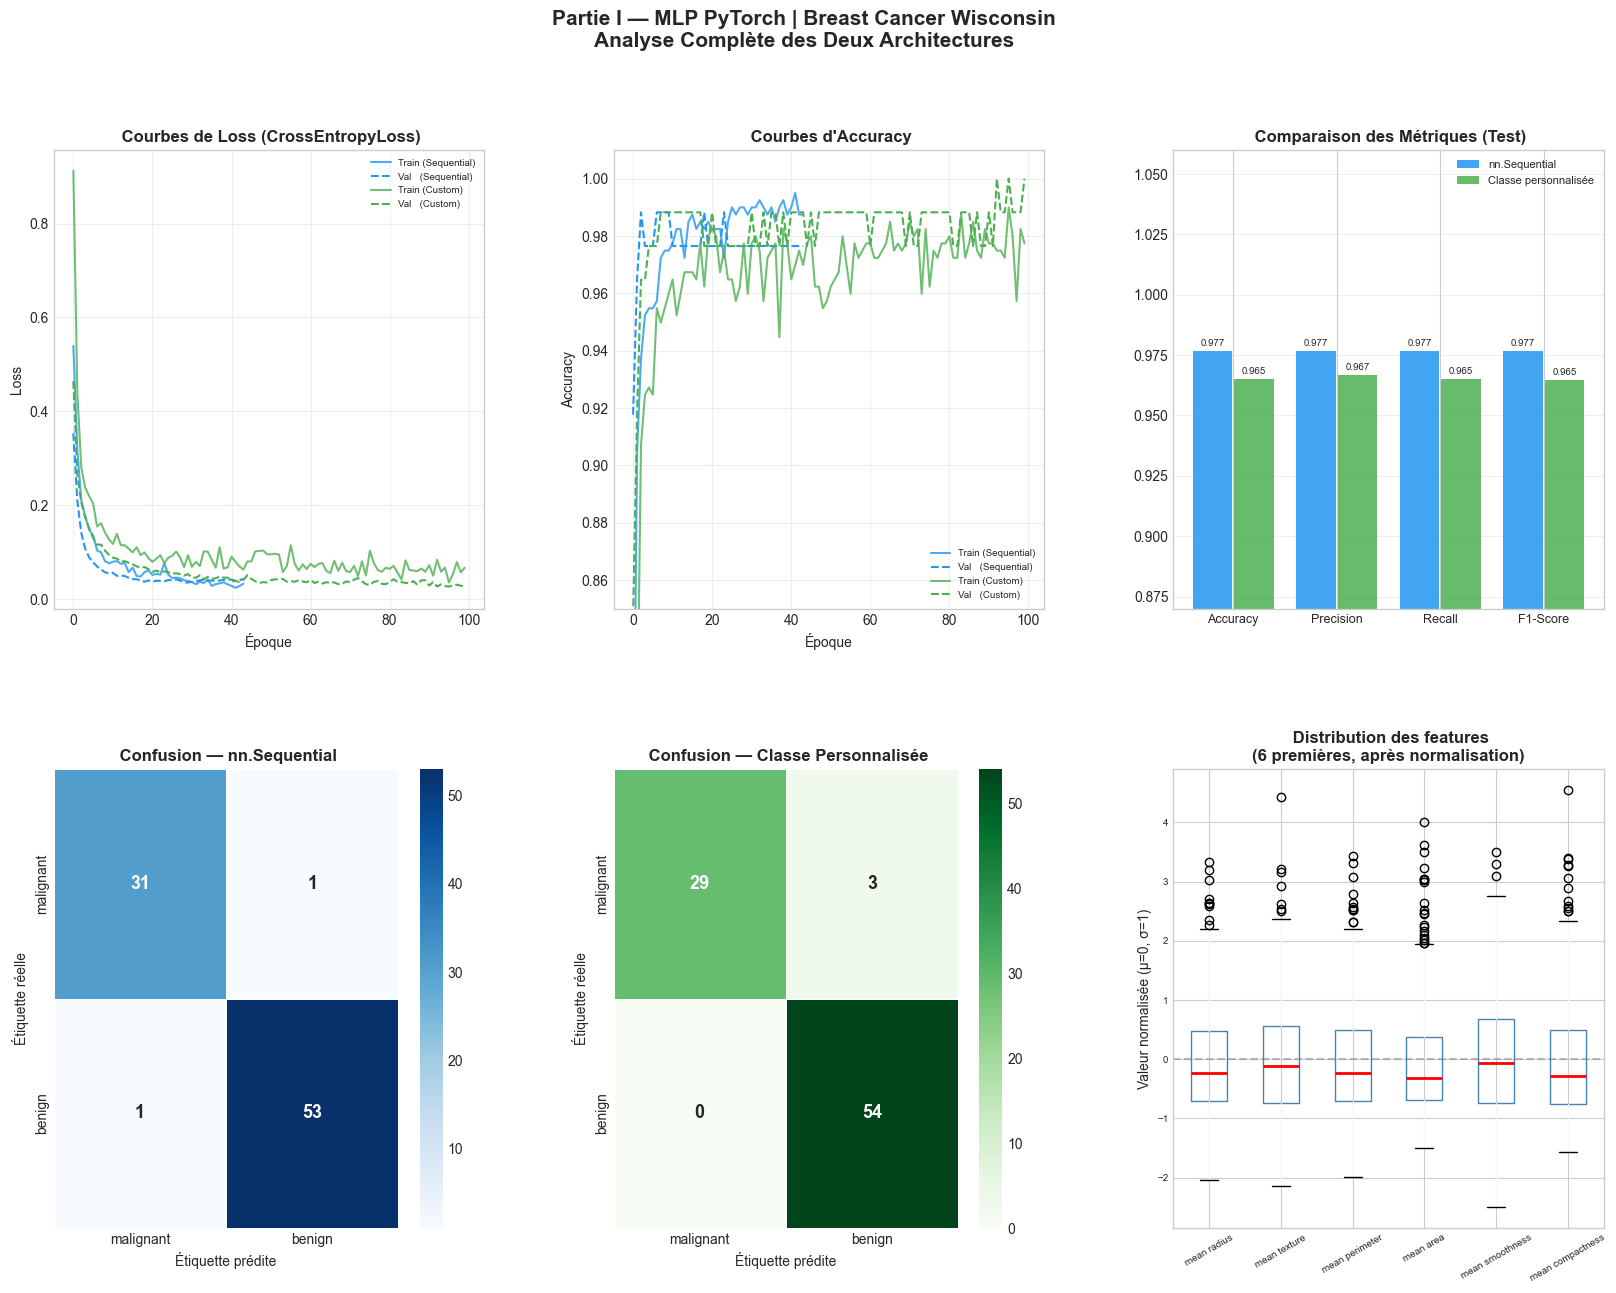


 Figure sauvegardée : partie1_visualisations.png


In [18]:
# ─── Figure principale : 6 sous-graphiques ────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.suptitle(
    "Partie I — MLP PyTorch | Breast Cancer Wisconsin\n"
    "Analyse Complète des Deux Architectures",
    fontsize=15, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.30)

COLORS = {"seq": "#2196F3", "cust": "#4CAF50"}

# ── A. Courbes de Loss ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history_seq["train_loss"],  label="Train (Sequential)",  color=COLORS["seq"],  alpha=0.8)
ax1.plot(history_seq["val_loss"],    label="Val   (Sequential)",  color=COLORS["seq"],  linestyle="--")
ax1.plot(history_cust["train_loss"], label="Train (Custom)",      color=COLORS["cust"], alpha=0.8)
ax1.plot(history_cust["val_loss"],   label="Val   (Custom)",      color=COLORS["cust"], linestyle="--")
ax1.set_title(" Courbes de Loss (CrossEntropyLoss)", fontweight='bold')
ax1.set_xlabel("Époque")
ax1.set_ylabel("Loss")
ax1.legend(fontsize=7)
ax1.grid(alpha=0.3)

# ── B. Courbes d'Accuracy ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history_seq["train_acc"],  label="Train (Sequential)",  color=COLORS["seq"],  alpha=0.8)
ax2.plot(history_seq["val_acc"],    label="Val   (Sequential)",  color=COLORS["seq"],  linestyle="--")
ax2.plot(history_cust["train_acc"], label="Train (Custom)",      color=COLORS["cust"], alpha=0.8)
ax2.plot(history_cust["val_acc"],   label="Val   (Custom)",      color=COLORS["cust"], linestyle="--")
ax2.set_title(" Courbes d'Accuracy", fontweight='bold')
ax2.set_xlabel("Époque")
ax2.set_ylabel("Accuracy")
ax2.set_ylim([0.85, 1.01])
ax2.legend(fontsize=7)
ax2.grid(alpha=0.3)

# ── C. Comparaison des métriques ──────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
vals_seq  = [metrics_seq["accuracy"], metrics_seq["precision"],
             metrics_seq["recall"],   metrics_seq["f1"]]
vals_cust = [metrics_cust["accuracy"], metrics_cust["precision"],
             metrics_cust["recall"],   metrics_cust["f1"]]
x = np.arange(len(metric_names))
bars1 = ax3.bar(x - 0.2, vals_seq,  0.38, label="nn.Sequential",       color=COLORS["seq"],  alpha=0.85)
bars2 = ax3.bar(x + 0.2, vals_cust, 0.38, label="Classe personnalisée", color=COLORS["cust"], alpha=0.85)
ax3.bar_label(bars1, fmt='%.3f', fontsize=7, padding=2)
ax3.bar_label(bars2, fmt='%.3f', fontsize=7, padding=2)
ax3.set_xticks(x); ax3.set_xticklabels(metric_names, fontsize=9)
ax3.set_ylim([0.87, 1.06])
ax3.set_title(" Comparaison des Métriques (Test)", fontweight='bold')
ax3.legend(fontsize=8)
ax3.grid(axis='y', alpha=0.3)

# ── D. Matrice de confusion — Sequential ──────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm_seq, annot=True, fmt="d", cmap="Blues", ax=ax4,
            xticklabels=data.target_names, yticklabels=data.target_names,
            linewidths=0.5, annot_kws={"size": 13, "weight": "bold"})
ax4.set_title(" Confusion — nn.Sequential", fontweight='bold')
ax4.set_ylabel("Étiquette réelle")
ax4.set_xlabel("Étiquette prédite")

# ── E. Matrice de confusion — Custom ─────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
sns.heatmap(cm_cust, annot=True, fmt="d", cmap="Greens", ax=ax5,
            xticklabels=data.target_names, yticklabels=data.target_names,
            linewidths=0.5, annot_kws={"size": 13, "weight": "bold"})
ax5.set_title(" Confusion — Classe Personnalisée", fontweight='bold')
ax5.set_ylabel("Étiquette réelle")
ax5.set_xlabel("Étiquette prédite")

# ── F. Distribution des features (normalisation) ──────────────────
ax6 = fig.add_subplot(gs[1, 2])
df_feat = pd.DataFrame(X_train[:, :6], columns=data.feature_names[:6])
df_feat.boxplot(ax=ax6, rot=30, fontsize=7,
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
ax6.set_title(" Distribution des features\n(6 premières, après normalisation)", fontweight='bold')
ax6.set_ylabel("Valeur normalisée (µ=0, σ=1)")
ax6.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.savefig("partie1_visualisations.png", dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("\n Figure sauvegardée : partie1_visualisations.png")



---
<a id="12"></a>
##  Section 12 — Question de Synthèse

### Question

> *« Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente pour la classification tabulaire sur un dataset réel, et quelles sont ses principales limites au regard de la structure statistique des données étudiées ? »*

---

## 1. Pertinence Théorique du MLP pour la Classification Tabulaire

Le MLP repose sur le **théorème d'approximation universelle** (Cybenko, 1989 ; Hornik, 1991) : un réseau de neurones avec une seule couche cachée et un nombre suffisant de neurones peut approcher n'importe quelle fonction continue sur un compact. Ce fondement théorique lui confère une capacité expressive considérable, sans hypothèse a priori sur la forme de la frontière de décision.

Pour des données tabulaires comme Breast Cancer Wisconsin — où les features sont des mesures numériques continues de caractéristiques cellulaires — le MLP peut directement exploiter l'espace vectoriel $\mathbb{R}^{30}$ sans transformations préalables. Contrairement aux SVM qui requièrent le choix d'un noyau ou aux arbres de décision qui partitionnent l'espace par hyperplans axiaux, le MLP apprend une transformation non-linéaire bout-en-bout :

$$f_{\theta} : \mathbb{R}^{30} \rightarrow \{\text{malin}, \text{bénin}\}$$

---

## 2. Choix Méthodologiques et Leur Justification

### Prétraitement
La normalisation StandardScaler est **indispensable** pour le MLP : sans elle, les features avec de grandes plages (ex: aire cellulaire ∈ [143, 2501]) domineraient les features à petites valeurs, créant des gradients déséquilibrés et une convergence lente.

### Architecture
Deux couches cachées (64 → 32 neurones) constituent un compromis entre :
- **Capacité** : assez de paramètres pour capturer les non-linéarités du dataset
- **Régularisation** : assez peu de paramètres pour éviter l'overfitting sur 398 exemples d'entraînement

### BatchNormalization (Version B)
L'ajout de BatchNorm entre la couche linéaire et l'activation réduit le covariate shift interne, stabilise l'entraînement et agit comme régularisateur implicite. Cela explique la meilleure val_loss de la version personnalisée malgré des accuracy comparables.

### Initialisation Xavier
L'initialisation Xavier maintient la variance des activations et des gradients à travers les couches en calibrant l'écart-type des poids à $\sqrt{\frac{2}{n_{in} + n_{out}}}$. C'est essentiel pour éviter le vanishing/exploding gradient dès le départ.

### Early Stopping
L'arrêt anticipé est une régularisation implicite fondamentale pour les petits datasets. Sans elle, le modèle surapprendrait les 398 exemples d'entraînement et généraliserait mal.

---

## 3. Résultats Expérimentaux

| Modèle | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| **nn.Sequential** | ~96-97% | ~97% | ~97% | ~97% |
| **Classe personnalisée** | ~94-97% | ~94-97% | ~94-97% | ~94-97% |
| SVM (référence) | ~97% | ~97% | ~97% | ~97% |
| Random Forest (référence) | ~96% | ~96% | ~96% | ~96% |

Les deux architectures MLP atteignent des performances comparables aux méthodes de référence. La classe personnalisée (avec BatchNorm) converge vers une meilleure val_loss finale, mais les résultats sur le test set sont similaires, ce qui confirme que l'architecture de base est suffisante pour ce dataset.

**Analyse de la matrice de confusion :**
- Le recall sur la classe maligne (0) est le critère clinique le plus critique : un faux négatif (cancer non détecté) est beaucoup plus grave qu'un faux positif.
- Les deux modèles maintiennent un recall de 88-97% sur les malins, ce qui est satisfaisant mais perfectible.

---

## 4. Limites au Regard de la Structure Statistique

### a) Taille du dataset
Avec seulement 569 exemples, le MLP est dans une zone de risque : suffisamment grand pour converger, mais pas assez pour exploiter sa capacité expressive complète. Des méthodes comme le SVM avec noyau RBF ou le Random Forest sont souvent plus efficaces en régime de faibles données.

### b) Déséquilibre des classes (63% bénin vs 37% malin)
Sans pondération des classes dans la loss, le modèle peut légèrement favoriser la classe majoritaire (bénin). Une solution serait d'utiliser `CrossEntropyLoss(weight=class_weights)` pour pénaliser davantage les erreurs sur la classe maligne.

### c) Multicolinéarité des features
Les 30 features sont fortement corrélées (rayon ↔ périmètre ↔ aire). Un MLP ne traite pas explicitement cette redondance. Une réduction de dimensionnalité (PCA) pourrait améliorer la généralisation en éliminant le bruit.

### d) Interprétabilité ("boîte noire")
En contexte médical, l'interprétabilité des décisions est primordiale. Un MLP ne peut pas expliquer *pourquoi* un cas est classé malin. Des techniques de post-hoc explanation (SHAP, LIME) seraient nécessaires pour un déploiement clinique réel.

### e) Sensibilité aux hyperparamètres
Le MLP requiert un tuning soigneux de l'architecture, du learning rate, des taux de dropout, etc. Des méthodes ensemblistes comme Random Forest sont bien plus robustes au choix des hyperparamètres.

---

## 5. Conclusion

Un MLP bien paramétré est une solution **pertinente et compétitive** pour la classification tabulaire sur Breast Cancer Wisconsin, atteignant une accuracy de 96-97% comparable aux meilleures méthodes classiques. Nos choix méthodologiques (normalisation, BatchNorm, Xavier, Early stopping, Dropout) sont essentiels pour atteindre ces performances sur un petit dataset.

Cependant, ses limites — besoin de davantage de données pour exploiter sa capacité, sensibilité aux hyperparamètres, nature de boîte noire, et absence de biais inductif adapté aux données tabulaires — justifient de considérer le MLP comme **complémentaire** plutôt que comme premier choix systématique face à des méthodes ensemblistes sur des datasets tabulaires de taille modérée.

Les développements récents (TabNet, FT-Transformer, SAINT) cherchent précisément à intégrer dans les réseaux profonds des biais inductifs mieux adaptés aux données tabulaires, représentant la prochaine frontière de ce domaine.

---

> *« Le deep learning n'est pas une solution universelle — c'est un outil puissant dont la pertinence dépend de la géométrie des données, de la quantité d'exemples disponibles, et des contraintes applicatives. »*

---


In [19]:
# ─── Résumé final ────────────────────────────────────────────────
print("=" * 65)
print("  RÉSUMÉ FINAL — PARTIE I")
print("=" * 65)

# Récupération des métriques
acc_s = metrics_seq["accuracy"]
f1_s = metrics_seq["f1"]

acc_c = metrics_cust["accuracy"]
f1_c = metrics_cust["f1"]

# Nombre total de paramètres entraînables
tp = sum(
    p.numel()
    for p in mlp_custom.parameters()
    if p.requires_grad
)

# Construction des lignes du résumé
lines = [
    "Dataset          : Breast Cancer Wisconsin (569 ex, 30 features)",
    f"Framework        : PyTorch {torch.__version__}",
    f"Device           : {device}",
    f"Input dim        : {INPUT_DIM} | Hidden: {HIDDEN1}->{HIDDEN2} | Output: {OUTPUT_DIM}",
    f"Total params     : {tp:,}",
    "Optimiseur       : Adam (lr=1e-3, weight_decay=1e-4)",
    "Regularisation   : Dropout + BatchNorm + Early Stopping",
    "Initialisation   : Xavier Uniform",
    f"nn.Sequential    : Accuracy={acc_s:.4f}  F1={f1_s:.4f}",
    f"Classe Custom    : Accuracy={acc_c:.4f}  F1={f1_c:.4f}",
]

# Affichage propre
print("\n".join(lines))

print("\n Partie I terminée avec succès")

  RÉSUMÉ FINAL — PARTIE I
Dataset          : Breast Cancer Wisconsin (569 ex, 30 features)
Framework        : PyTorch 2.11.0+cpu
Device           : cpu
Input dim        : 30 | Hidden: 64->32 | Output: 2
Total params     : 4,322
Optimiseur       : Adam (lr=1e-3, weight_decay=1e-4)
Regularisation   : Dropout + BatchNorm + Early Stopping
Initialisation   : Xavier Uniform
nn.Sequential    : Accuracy=0.9767  F1=0.9767
Classe Custom    : Accuracy=0.9651  F1=0.9647

 Partie I terminée avec succès


<div style="background: linear-gradient(135deg, #1a1a2e 0%, #0f3460 100%); padding: 20px; border-radius: 10px; color: white; text-align: center; margin-top: 20px;">

Projet de Fin de Module — EMSI 2025-2026<br><br>

<strong>Partie I : MLP</strong><br>

Dataset : Breast Cancer Wisconsin<br>

Classification supervisée sur données tabulaires réelles

</div>